In [3]:
import pandas as pd

## Read data 

In [4]:
df = pd.read_csv("SMSSpamCollection",sep = "\t", header = None, names = ["labels","message"])
df.head()
df["labels"].value_counts(normalize=True)
duplicated_num = df.duplicated().sum()

## Cleaning data

In [5]:
df = df.drop_duplicates()
df["labels"].unique()
df["message"].str.strip().eq("").sum()

np.int64(0)

## Text Preprocessimg

In [6]:
df["message_lowercase"] = df["message"].str.lower()
df.head()

,labels,message,message_lowercase
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


### Tokenizing

In [7]:
words_before = set(" ".join(df["message"]).split())
words_after = set(" ".join(df["message"].str.lower()).split())

print(len(words_before))
print(len(words_after))

15691
13579


In [8]:
df["tokens"] = df["message_lowercase"].str.split()
df.head()

,labels,message,message_lowercase,tokens
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...","[go, until, jurong, point,, crazy.., available..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,"[ok, lar..., joking, wif, u, oni...]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,"[u, dun, say, so, early, hor..., u, c, already..."
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...","[nah, i, don't, think, he, goes, to, usf,, he,..."


In [9]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### remove stopword

In [10]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

In [11]:
def remove_stopword (tokens):
    result = []
    for word in tokens :
        if word not in stop_words:
            result.append(word)

    return result

df["token_no_stopword"] = df["tokens"].apply(remove_stopword)

df.head()

,labels,message,message_lowercase,tokens,token_no_stopword
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...","[go, until, jurong, point,, crazy.., available...","[go, jurong, point,, crazy.., available, bugis..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,"[ok, lar..., joking, wif, u, oni...]","[ok, lar..., joking, wif, u, oni...]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,"[u, dun, say, so, early, hor..., u, c, already...","[u, dun, say, early, hor..., u, c, already, sa..."
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...","[nah, i, don't, think, he, goes, to, usf,, he,...","[nah, think, goes, usf,, lives, around, though]"


### stemming

In [12]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stem_words(tokens):

    result = []
    for word in tokens:
        result.append(stemmer.stem(word))
    return result

df["stem_words"] = df["token_no_stopword"].apply(stem_words)

df.head()

,labels,message,message_lowercase,tokens,token_no_stopword,stem_words
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...","[go, until, jurong, point,, crazy.., available...","[go, jurong, point,, crazy.., available, bugis...","[go, jurong, point,, crazy.., avail, bugi, n, ..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,"[ok, lar..., joking, wif, u, oni...]","[ok, lar..., joking, wif, u, oni...]","[ok, lar..., joke, wif, u, oni...]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[free, entry, 2, wkly, comp, win, fa, cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,"[u, dun, say, so, early, hor..., u, c, already...","[u, dun, say, early, hor..., u, c, already, sa...","[u, dun, say, earli, hor..., u, c, alreadi, sa..."
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...","[nah, i, don't, think, he, goes, to, usf,, he,...","[nah, think, goes, usf,, lives, around, though]","[nah, think, goe, usf,, live, around, though]"


### lemmatization

In [13]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
def lemma_word (tokens):
    result = []
    for word in tokens:
        result.append(lemmatizer.lemmatize(word))

    return result

df["lemmatized_word"] = df["token_no_stopword"].apply(lemma_word)

df.head()

,labels,message,message_lowercase,tokens,token_no_stopword,stem_words,lemmatized_word
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...","[go, until, jurong, point,, crazy.., available...","[go, jurong, point,, crazy.., available, bugis...","[go, jurong, point,, crazy.., avail, bugi, n, ...","[go, jurong, point,, crazy.., available, bugis..."
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,"[ok, lar..., joking, wif, u, oni...]","[ok, lar..., joking, wif, u, oni...]","[ok, lar..., joke, wif, u, oni...]","[ok, lar..., joking, wif, u, oni...]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[free, entry, 2, wkly, comp, win, fa, cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin...","[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,"[u, dun, say, so, early, hor..., u, c, already...","[u, dun, say, early, hor..., u, c, already, sa...","[u, dun, say, earli, hor..., u, c, alreadi, sa...","[u, dun, say, early, hor..., u, c, already, sa..."
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...","[nah, i, don't, think, he, goes, to, usf,, he,...","[nah, think, goes, usf,, lives, around, though]","[nah, think, goe, usf,, live, around, though]","[nah, think, go, usf,, life, around, though]"


## TF/IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["message"])

Y = df["labels"].map({"ham" : 0 , "spam" : 1})

Y.head()

0    0
1    0
2    1
3    0
4    0
Name: labels, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state = 20 ,stratify=Y)

print(Y.value_counts())
print(x_train.shape)
print(x_test.shape)

labels
0    4516
1     653
Name: count, dtype: int64
(4135, 8713)
(1034, 8713)


## Naive Bayes model

In [17]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(x_train,y_train)

y_pred_nb = model_nb.predict(x_test)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred_nb)
print(accuracy)

0.9564796905222437


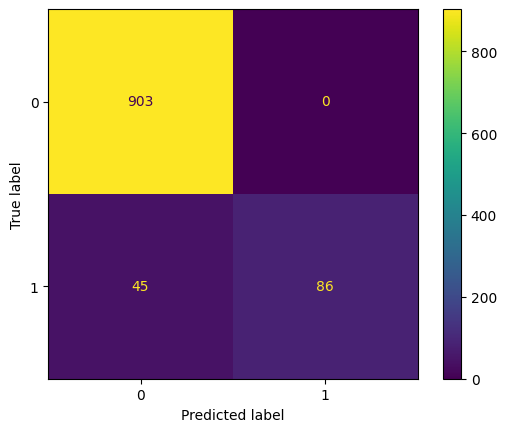

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_nb)

plt.show()

In [20]:
from sklearn.metrics import classification_report

np_report = classification_report(y_test,y_pred_nb)

print(np_report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       903
           1       1.00      0.66      0.79       131

    accuracy                           0.96      1034
   macro avg       0.98      0.83      0.88      1034
weighted avg       0.96      0.96      0.95      1034



## Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()

model_lr.fit(x_train,y_train)

y_pred_lr = model_lr.predict(x_test)


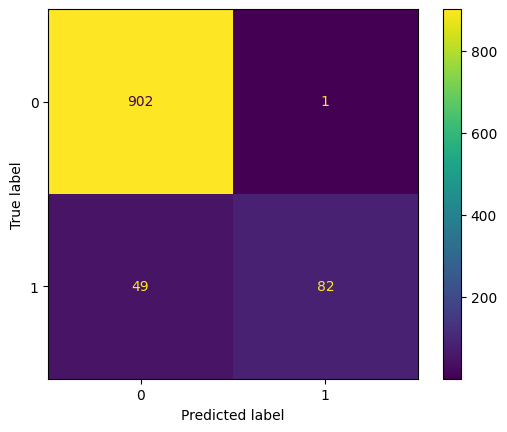

0.9516441005802708


In [24]:
lr_accuracy = accuracy_score(y_test,y_pred_lr)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_lr)
plt.show()
print(lr_accuracy)

In [25]:
lr_report = classification_report(y_test,y_pred_lr)
print(lr_report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       903
           1       0.99      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.95      0.95      0.95      1034



## Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state= 30)

model_dt.fit(x_train,y_train)

y_pred_dt = model_dt.predict(x_test)

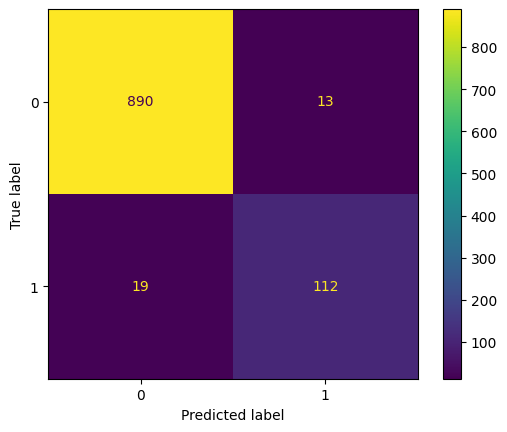

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

In [28]:
dt_report = classification_report(y_test,y_pred_dt)
dt_accuracy = accuracy_score(y_test,y_pred_dt)

print(dt_accuracy)
print(dt_report)

0.9690522243713733
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       903
           1       0.90      0.85      0.88       131

    accuracy                           0.97      1034
   macro avg       0.94      0.92      0.93      1034
weighted avg       0.97      0.97      0.97      1034



## Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=40)

model_rf.fit(x_train,y_train)

y_pred_rf = model_rf.predict(x_test)


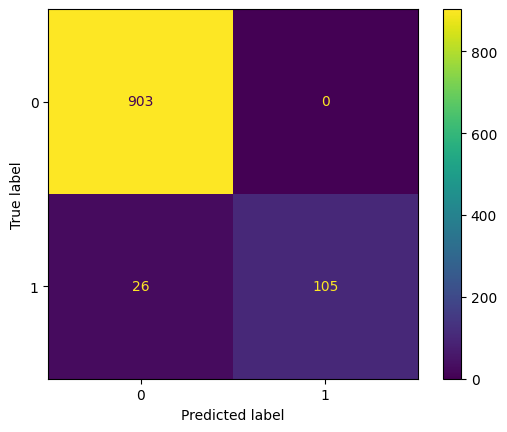

0.9748549323017408


In [32]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)

plt.show()

print(rf_accuracy)

In [33]:
rf_report = classification_report(y_test , y_pred_rf)

print(rf_report)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       903
           1       1.00      0.80      0.89       131

    accuracy                           0.97      1034
   macro avg       0.99      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034



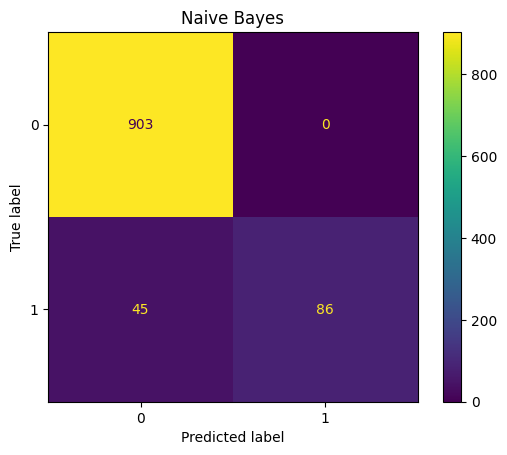

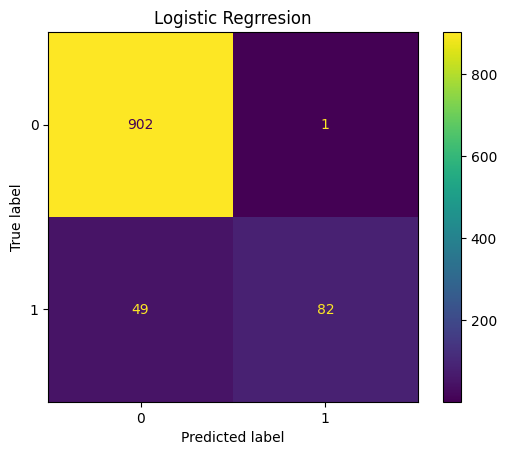

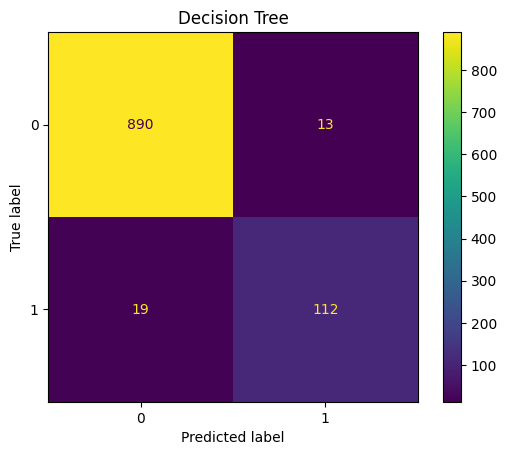

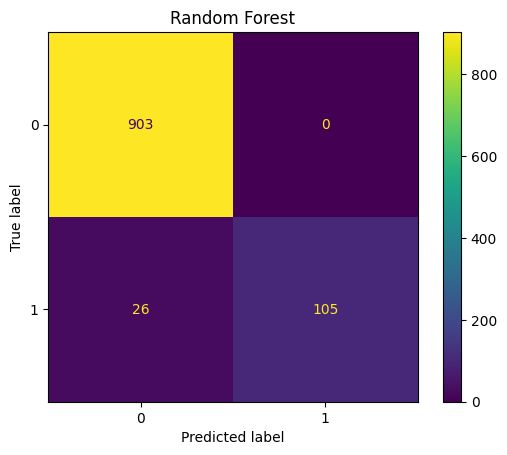

In [34]:
models = {
    "Naive Bayes" : y_pred_nb,
    "Logistic Regrresion" : y_pred_lr,
    "Decision Tree" : y_pred_dt,
    "Random Forest" : y_pred_rf
}

for name , y_pred in models.items():
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred)


    plt.title(name)
    plt.show()